<a href="https://colab.research.google.com/github/Kempler-Group/Figure_Code/blob/main/P4E_Visualizing_Data_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title
%%capture
!pip install softpotato
!pip install imageio kaleido==0.2.1

In [ ]:
# @title
'''
This notebook will use matplotlib and numpy to manipulate data
and prepare example plots for teaching data visualization. The notebook uses
softpotato to prepare a set of simulated voltammograms which are used to
prepare example plots and figures.
'''

import matplotlib.pyplot as plt
import pandas as pd
import softpotato as sp
import numpy as np

#Create a waveform
Eini = -0.5
Efin = 0.5
sr = 0.1
dE = 0.01
wf = sp.technique.Sweep(Eini=Eini, Efin=Efin, sr=sr, dE=dE)

#Establish constants
n = 1
A = 1
E0 = 0
cOb = 0
cRb = 1e-6
DO = 1e-5
DR = 1e-5
alpha = 0.5

#rate constant array
k0 = np.array([1e-2, 1e-3, 1e-4, 1e-5])

nk = k0.size

i_k = np.zeros([wf.t.size, nk]) # initialize array

for x in range(nk):
  sim = sp.simulate.E(wf, n, A, E0, cOb, cRb, DO, DR, k0[x], alpha)
  sim.run()

  #save current solutions to array
  i_k[:,x] = sim.i

#sp.plotting.plot(wf.E, i*1e3, ylab='$i$', fig=1, show=1)

## Create a set of representative voltammograms
# These will be used for introducing plotting functions and styles

wf_10mVs = sp.technique.Sweep(Eini=-0.5, Efin=0.5, sr=0.010)
wf_20mVs = sp.technique.Sweep(Eini=-0.5, Efin=0.5, sr=0.020)
wf_30mVs = sp.technique.Sweep(Eini=-0.5, Efin=0.5, sr=0.030)

sim = sp.simulate.E(wf_10mVs, n, A, E0, cOb, cRb, DO, DR, 1e1, alpha)
sim.run()
i_10 = sim.i

sim = sp.simulate.E(wf_20mVs, n, A, E0, cOb, cRb, DO, DR, 1e1, alpha)
sim.run()
i_20 = sim.i

sim = sp.simulate.E(wf_30mVs, n, A, E0, cOb, cRb, DO, DR, 1e1, alpha)
sim.run()
i_30 = sim.i

E = wf_10mVs.E
i = i_10

E_10 = wf_10mVs.E
E_20 = wf_20mVs.E
E_30 = wf_30mVs.E

t_10 = wf_10mVs.t
t_20 = wf_20mVs.t
t_30 = wf_30mVs.t

# Chapter 4



## Section 4.1.1 - Introduction

### Data Visualization

In this paragraph we will introduce the basics of using python to visualize data produced from electrochemistry experiments and simulations. There are a number of texts dedicated exclusively to data visualization which informed many of the decision recommendations in this textbook. Readers should consult these original texts for more background on effective communication via figures.

Edward Tufte authored a foundational of modern data visualization, *The Visual Display of Quantitative Information* [[1]](#tufte). This text introduces the concept of the "data-to-ink" ratio, which directs authors to maximize the quantity of ink (here, pixels) devoted to displaying data, relative to the total ink (pixels) used to prepare a chart. In a pythonic context, this means selecting appropriate marker sizes and linewidths and minimizing the amount of extraneous annotations, decorations, and grid lines which do not contribute new, quantitative information to the figure. These elements are deemed "chartjunk" by Tufte. The wide variety of colors and design elements made available by plotting libraries should thus be handled with care... these elements should be considered seasoning for a striking data set and not the other way around!

William Cleveland conducted experiments on visual perception and thereby developed an empirical set of guidelines for plotting. Cleveland's design decisions aim to avoid misleading the reader, by prioritizing ways of comparing data which are easily distinguished by the human eye [[2]](#cleveland93). Scatter plots and "dot plots" allow data to be compared on a common axis, a direct comparison which minimizes "ink clutter" provided by bar charts. Bubble charts, while useful for trivariate data sets, force the reader to decide whether to quantify by radius or area, leading to inaccurate interpretations. At the bottom of Cleveland's hierarchy of accuracy are shading and hue, which frequently lead to imprecise comparisons. Thus, quantitative comparisons of electrochemistry data should be made using markers on a well-labeled axis first, and rely on secondary plotting tools such as color/shading primarily to separate categorical variables.

John Tukey coined the term "Exploratory Data Analysis", as a foil to the tempting and perhaps too common "Confirmatory Data Analysis"[[3]](#tukey). Tukey encouraged visualizing data prior to modeling and many of his proposed tools, such as the box-and-whisker plot, are featured in the `seaborn` library for data analysis. An iterative approach to filtering and transforming data prior to visualization and modeling is today much easier with access to modern computing and the notebook format.

Most recently, Claus Wilke authored a comprehensive and open source text on visualizing data which is accompanied by a GitHub repository for the R Markdown files used to prepare the book [[4]](#wilke). The emphasis of this book is *not* on the code used to produce figures but the fundamental principles of data visualization. The content of the book ranges from basic principles of visualizations to design decisions in figure design, and suggestions for selecting software and file types.

First and foremost, data visualizations should be *precise*, *efficient*, and *reproducible* in their presentation of quantitative results. Preparing figures in python (or any other written coding language) makes most design decisions beyond default settings explicit. Decisions on plot styles, linewidths, and colors impact the precision of a visualization as it is perceived by the reader. Efficiency of design means that any features which do not themselves contain quantitative information are included to improve precision. Authors should make their original code used to convert raw data into a figure available on open source repositories to ensure their presentations are reproducible.

### Introduction to Pyplot
There are many different libraries available for plotting data in python, but this text will introduce the topic using "pyplot", a collection of functions within the Matplotlib library. Pyplot is based off the plotting languagae used in the MATLAB software and preserves much of the syntax and style of that environment. The preferred way to generate plots in pyplot is by modifying objects within a figure "container". The figure is thus constructed through a series of specific commands, adding data to axes and explicitly modifying the information and style presented via legends, labels, ticks, lines, and markers. The result of these commands is monitored via the "artist".

Pyplot balances the use of explicit, script-based figure preparation with high-level methods that remove the need for users to understand the mathematical operations required to produce an image.

Compared to plotting software that relies on a graphical user interface, users may find that using python to produce the <i>first</i> plot or figure requires additional time and effort. Nevertheless, this upfront cost is quickly recovered by saving scripts and frequently used commands such that professional plots can be generated from new data sets in seconds. The added benefit is that all modifications to original source data are saved in the code used to produce the figure and thus reproducible by other scientists.

## Section 4.1.2 - Elements of a Figure

A scientific figure can be broken down into a set of key elements which are used to convey quantitative information. One or more axes are used to convey information using spatial position on the page and should be clearly labeled with the quantity and unit of measurement to provide a key to the reader. Ticks provide a sense of scale, and are particularly helpful for logarithmic plots. Data sets are best distinguished by the shape and color of markers or lines, but the size and color of markers can be used to provide auxilliary information. Lastly, annotations and legends are essential for identifying multiple data series and calling attention to specific features. Across all elements, consistent aesthetics—such as standardized fonts and colorblind-friendly palettes—ensure the figure is accessible and professional for publication.

```python
fig, ax = plt.subplots(1,1,figsize=(3,3))
```

The subplots function is used to initiate a figure and a set of axes, with the quantity of subplot axes defined by the number of rows and columns. A single panel figure is created using:
```python
fig, ax = plt.subplots(rows=1, columns=1)
```
where the output of the function is a tuple containing a figure `fig` and an array with a single axis object `ax`.

Data are directly added to the axes using `plot`:

```python
ax.plot(E,i)
```

which adds a new `line` object to the plot that is defined by the data as well as the variable color, size, line-style, and marker shape.

During routine plotting of data, it is not necessary to explicitly assign these variables, as pyplot generates a default cycle of colors. The line-style can be quickly modified using an inline format string that specifies across a limited set of colors markers, and line styles. The syntax for the formatting strings is [color][marker][line], e.g. 'rs-' for a set of red `r`, square `s` markers connected by a continuous line `-`.

```python
ax.plot(E,i,'rs-')
```

The available short codes include

Colors
|Code|Description|
|---|---|
|`r`|red|
|`y`|yellow|
|`g`|green|
|`b`|blue|
|`c`|cyan|
|`m`|magenta|
|`k`|black|
|`w`|white|

Markers
|Code|Description|
|---|---|
|`.`|point|
|`o`|circle|
|`x`|x-mark|
|`s`|square|
|`d`|diamond|
|`+`|plus|
|`^`|triangle|
|`*`|star|

Line-styles
|Code|Description|
|---|---|
|`-`|solid line|
|`--`|dashed line|
|`:`|dotted line|
|`-.`|dash-dot line|

<br>
A much wider variety of linestyles and colors can be specified using keyword arguments, for example:

```python
ax.plot(E,i, markersize=10, marker='>', linewidth=2, color='skyblue')
```

Matplotlib provides numerous options for markers and named colors and users are encouraged to consult the most recent documentation for a comprehensive summary of available plotting tools. In addition to named colors, users may specificy custom colors in a few ways

#### RGBA

RGBA stands for "red", "green", "blue", and "alpha", and is a method of specifying the color intensity within the closed interval [0,1]. The fourth string value is optional and will default to 1. Red is indicated by (1, 0, 0) and purple can be indicated by (0.5, 0, 1). This form of input is most convenient for quickly generating a monochromatic color series.

#### Hex Codes

Hex codes are an alternate representation of RGB tuples and these are the typical way that colors are specified within other design software interfaces. The widespread use of hex codes to represent color values dates back to the early days of web design. The RGB value is represented by a set of three pairs following a pound sign `#` and a compact, base-16 numbering system that allows 255 values to be represented by two digits. Arabic numerals 0-9 are followed by upper-case letters (A-F) for 16 total symbols. As representative examples, red can be indicated by ##FF0000 and purple can be indicated by ##8000FF.

```python
fig, ax = plt.subplots(1,1,figsize=(3,3))
ax.plot(E_10,i_10,'-', color='#8000FF')
```

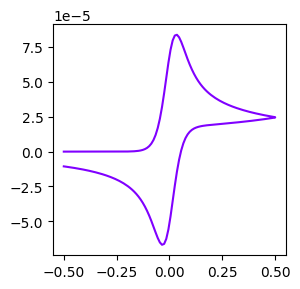

In [ ]:
# @title Figure 1
fig, ax = plt.subplots(1,1,figsize=(3,3))
ax.plot(E_10,i_10,'-', color='#8000FF')

### Axis labels and controlling ticks.

In addition to a series of data points, any complete plot must specify the meaning of the x- and y-axes. Labels are applied using `ax.set_xlabel()` and general modifications to the axes are performed using the family of `ax.set_*` methods.

```python
ax.set_xlabel('$E$ (V vs. Ref)')
ax.set_ylabel('$i$ (A)')
```

The limits of the axes and positions of major and minor ticks can be modified using `ax.set_ylim()`and `ax.set_xticks()`, respectively. In the following example, we use the `np.arange()` method to quickly generate a set of values across a desired range. The axis limits will be set by default to maximize the use of the available space contained within the figure, but occassionally require user adjustments. If ticks are specified manually, at least three ticks should be present on the axis and additional unlabeled "minor" ticks can be used to provide further precsision provided that they do not contribute to unnecessary clutter.

```python
ax.set_xlabel('$E$ (V vs. Ref)')
ax.set_ylabel('$i$ (A)')

ax.set_ylim(-1e-4, 1.3e-4)

ax.set_xticks(np.arange(start=-0.5,stop=0.6,step=0.25))
ax.minorticks_on()
```


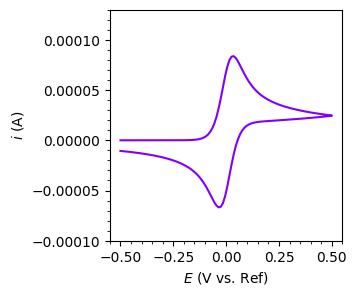

In [ ]:
# @title Figure 2
ax.set_xlabel('$E$ (V vs. Ref)')
ax.set_ylabel('$i$ (A)')

ax.set_ylim(bottom=-1e-4,top=1.3e-4)

ax.set_xticks(np.arange(start=-0.5,stop=0.6,step=0.25))
ax.minorticks_on()

fig

### Formatting the axis scale

The default axis is plotted on a linear scale with standard decimal notation. For very small (<10<sup>-4</sup>) or very large (>10<sup>4</sup>) numbers, the number format of the axis may automatically switch to scientific notation.

Users may specify the number format explicitly using

```python
ax.ticklabel_format(style='sci', axis='y')
```
where the style could have also been applied to `'x'` or `'both'`.

Many experiments in electrochemistry (e.g. Tafel plots, electrochemical impedance spectroscopy data) are best visualized on semi-log or log-log plots. Individual axes can be modified using

```python
ax.set_yscale('log')
```

whereas a log-log plot can be more quickly prepared using

```python
ax.loglog()
```

which immediately sets both axes to a logarithmic scale and does not require any arugments when applied after the individual data sets have been assigned to the axes.

### Generating plots with multiple data series

In many electrochemistry experiments, the key result is the presentation of a change in current or voltage in response to a experimental parameter of interest. For example, results from cyclic voltammery are best understood when compared across two or more scan rates. Multiple data series may be added to a set of axes by repeated `ax.plot()` commands, with each call of the function producing a new 2D line object. It is best practice to label these objects as they are created, and this practice makes other tasks such as legend generation and further modifications to specific lines much faster.

```python
fig, ax = plt.subplots(1,1,figsize=(4,4))
ax.plot(E_10,i_10,label='10 mV/s')
ax.plot(E_20,i_20,label='20 mV/s')
ax.legend() #This function automatically implements labels specified during the ax.plot() command
```

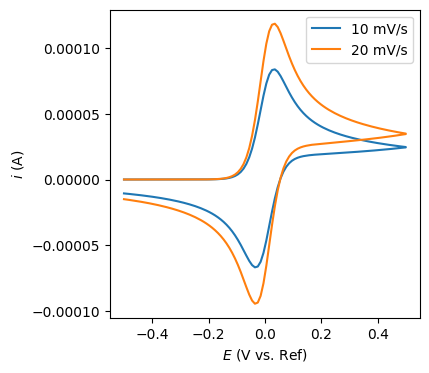

In [ ]:
# @title Figure 3
fig, ax = plt.subplots(1,1,figsize=(4,4))
ax.plot(E_10,i_10,label='10 mV/s')
ax.plot(E_20,i_20,label='20 mV/s')

ax.set_xlabel('$E$ (V vs. Ref)')
ax.set_ylabel('$i$ (A)')

ax.legend()

Changes to line styles can also be made after the plot has been created by assigning the line object to a variable and using the `.set_` family of methods.

```python
lines = ax.lines
lines[0].set_color('red')
lines[1].set_color('blue')
```

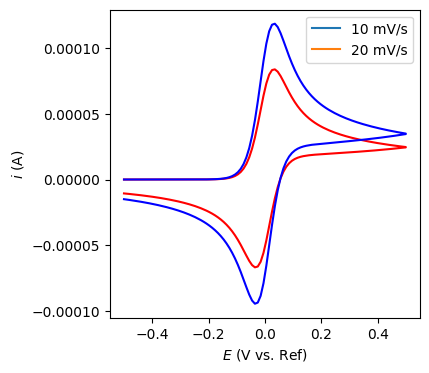

In [ ]:
# @title Figure 4
lines = ax.lines
lines[0].set_color('red')
lines[1].set_color('blue')

fig

### Annotations

An alternate approach to legends is to directly annotate individual voltammetry scans with text labels. Labels are also commonly used to track specific current peaks and indicate the scan direction. Annotations are primarily handled with `ax.text()`, `ax.annotate()`, or `ax.plot()` to create text, arrows, and general marker/line objects, respectively.

Labels should clearly correspond to a specific data series through location and color. The text command places a text string beginning at a set of `x,y` coordinates. For example:

```python
ax.text(0.3, 5e-5,'10 mV/s',color='blue')
ax.text(0.3, 1e-5,'20 mV/s',color='red')
```

can be used to label the previously generated voltammetric scans and annotations, e.g.,

```python
ax.annotate(
  xy=(-0.4,1e-5)
  xytext(-0.4,2e-5)
  arrowprops=dict(facecolor='black', shrink=0.05, headwidth=10)
  )
```

can be used to produce arrows which identify peaks or indicate the initial direction of the scan (example shown here).


Text(-0.4, 1e-05, '')

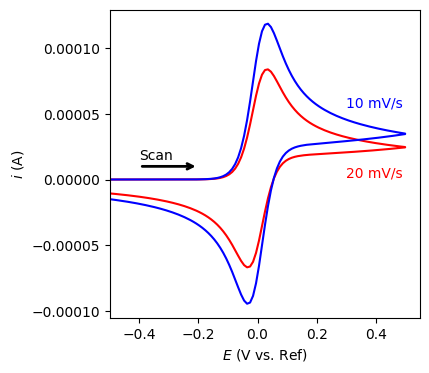

In [ ]:
# @title Figure 5
fig, ax = plt.subplots(1,1,figsize=(4,4))
ax.plot(E_10,i_10,label='10 mV/s')
ax.plot(E_20,i_20,label='20 mV/s')

ax.set_xlabel('$E$ (V vs. Ref)')
ax.set_ylabel('$i$ (A)')

lines = ax.lines
lines[0].set_color('red')
lines[1].set_color('blue')

ax.set_xlim(-0.5,0.55)

ax.text(0.3, 5.5e-5,'10 mV/s',color='blue')
ax.text(0.3, 0.2e-5,'20 mV/s',color='red')

ax.text(-0.4,1.5e-5,'Scan')

ax.annotate('',
  xy=(-0.2,1e-5),
  xytext=(-0.4,1e-5),
  arrowprops=dict(arrowstyle='->', lw=2, color='black'))

## Section 4.1.3 Modifying figures using object-oriented programming

### State-based programming

*State-based* programming uses implicit assignment of commands to a currently "active" figure or set of axes, whereas *object-oriented* programming explicitly assigns commands to a specific "object". When creating multiple figures within a single loop, an extended script, or notebook environment, this avoids errors in assignment and produces more readable code. Although pyplot includes functionality for state-based programming, users are encouraged to strive to master the explicit approach (exemplified by most of the commands above).

State-based commands typically begin from the `plt` library. For example, the first figure in an enviroment can be created and populated with data using `plt.figure(n)`. This function sets the currently active figure to "n" and will create a new figure object if this figure does not already exist.

```python
plt.figure(1) # creates a figure, numbered "1"
plt.plot(E_10,i_10,label='10 mV/s') # assigns data to the currently active figure (1)
```
From here, the figure can be modified using general `plt` commands which implicitly modify the active figure (1)
```python
plt.ylim([-7e-5, 9e-5])
plt.xlabel('$E$ (V vs. Ref)')
plt.ylabel('$i$ (A)')
```
Additional data will by default be assigned to the currently active figure.
```python
plt.plot(E_20,i_20,label='20 mV/s') # assigns more data to the currently active figure (1)
```
But a second figure can alternatively be created to host an independent data set.
```python
plt.figure(2)
plt.plot(E_20,i_20,label='20 mV/s')
```
with additional commands related to figure formatting being applied to earlier figures by modifying the active figure (`plt.figure(1)`)

Note that while `plt` commands—especially those used to adjust the layout or save figures—may generally be incorporated within an OOO set of commands, which activate the desired figure, it is generally preferable to rely on explicit assignment.

```python
plt.tight_layout() # adjusts the padding of the active figure and layout of the axes labels
plt.savefig('FIGURETITLE.png', dpi=200) # saves the active figure with a specified file format (here, .png) and optional dots per inch (dpi).
```

### Object-oriented programming

In comparison to state-based programming, *object-oriented* programming is preferable for batch-processing of multiple data files or cycles, provies more compact support for preparing multi-panel figures, and generally leads to more readable code. Although figures can be assembled piecewise and then later assembled into multipanel figures within presentation or design software, the use of python for figure preparation maintains consistency across multiple figures and leads to traceable edits to the raw data.

In the pyplot hierarchy, the figure is the overall canvas being modified and the axes are specific plots/subplots within the canvas. For a multipanel figure, the axes object is a 2D array where a specific set of axes within a multi-panel figure can be called by specifying the [row,column]. To demonstrate the utility of this format, we will create a four-panel figure as an example of a figure style found in scientific publications
```python
multifig, multiax = plt.subplots(2, 2, figsize=(3,3))
```
Figures may be assigned to individual axes, here the second row and the first column, in piecewise fashion using
```python
multiax[1,0].plot(E_10,i_10,label='10 mV/s')
```
A set of data or simulations is more rapidly applied across four separate panels using lists. Here an array of simulated currents resulting from various rate constants (`[1e2, 1e0, 1e-2, 1e-4]`) in cm/s is applied to a 1 x 4 multi-panel figure.

```python
multifig, multiax = plt.subplots(1, 4, figsize=(8,2))

for n in range(0,4): # Loop across four axes and four data sets
  multiax[n].plot(E,i_k[:,n]) # Select specific current data from an array
  multiax[n].set_xlabel('$E$ (V vs. Ref)') # Apply a consistent x-axis label
  multiax[n].set_ylim([-3e-4, 3e-4]) # Apply a consistent y-axis range

multiax[0].set_ylabel('$i$ (A)') # Set a single y-axis label
plt.tight_layout() # Avoid overlapping axes
```

For a shared set of x- or y-axes across the multipanel figure, a more compact figure can be prepared by removing axis labels within the loop and applying them to specific sets of axes, e.g.
```python
for n in range(1,4):
  multiax[n].set_yticklabels([])`
```

Labels for subfigures can be generated using the plotting function and an alphanumeric list.
```python
labels = list('abcdefghijk')
for n in range(0,4):
  multiax[n].text()
```

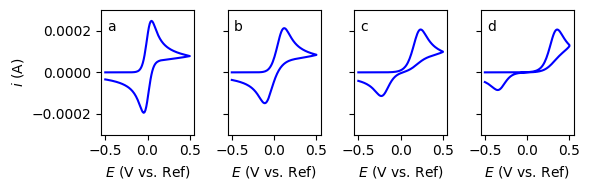

In [ ]:
# @title Figure 6
multifig, multiax = plt.subplots(1, 4, figsize=(6,2))

labels = list('abcdefghijkl')
for n in range(0,4): # Loop across four axes and four data sets
  multiax[n].plot(E,i_k[:,n],'b-') # Select specific current data from an array
  multiax[n].set_xlabel('$E$ (V vs. Ref)') # Apply a consistent x-axis label
  multiax[n].set_ylim([-3e-4, 3e-4]) # Apply a consistent y-axis range
  multiax[n].text(-0.475, 2e-4, labels[n])

for n in range(1,4):
  multiax[n].set_yticklabels([]) # Remove labels but keep ticks

multiax[0].set_ylabel('$i$ (A)') # Set a single y-axis label
plt.tight_layout() # Avoid overlapping axes

When a square figure is desired (e.g. 2 x 2), a simple loop across the rows and columsn becomes more challenging. The array should first be flattened to maintain compatibility with a one-dimensionally loop using the `enumerate` function.

```python
multifig, multiax = plt.subplots(2, 2, figsize=(4,4))

for n, ax in enumerate(multiax.flatten()):
    ax.plot(E, i_k[:,n], 'b-')
    ax.text(-0.475, 2e-4, labels[n])
    ax.set_ylim([-3e-4,3e-4]) # Maintain constant y-axis across figures

plt.tight_layout() # Avoid overlapping axes
```

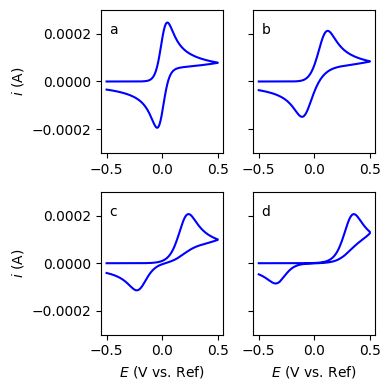

In [ ]:
# @title Figure 7
multifig, multiax = plt.subplots(2, 2, figsize=(4,4))

for n, ax in enumerate(multiax.flatten()):
    ax.plot(E, i_k[:,n], 'b-')
    ax.text(-0.475, 2e-4, labels[n])
    ax.set_ylim([-3e-4,3e-4]) # Maintain constant y-axis across figures

multiax[0,1].set_yticklabels([])
multiax[1,1].set_yticklabels([])

multiax[0,0].set_ylabel('$i$ (A)')
multiax[1,0].set_ylabel('$i$ (A)')

multiax[1,0].set_xlabel('$E$ (V vs. Ref)')
multiax[1,1].set_xlabel('$E$ (V vs. Ref)')

plt.tight_layout() # Avoid overlapping axes

These examples demonstrate how judicious use of object oriented programming can be used to quickly digest large data sets into well-organized, consistent, and reproducible multi-panel figures.

## Section 4.1.4 Preparing Publication Quality Figures

### Standardizing aesthetics

Coherent design within documents and presentations follows from a consistent set of stylistic choices for colors, texts, and markers. Python learners preparing their first figures can default to pre-set styles, whereas intermediate coders will enjoy a vast canvas of options for customizing the appearance of individual figures. Such customization may lead to time consuming revisions as the number of unique design decisions expand. For this reason, advanced users of matplotlib and other plotting featuers will treat each specific design choice as a variable, which supports cohert design decisions which can be modified with a few key strokes.

As initial figures are modified to fit a desired appearance, users should establish variables such as colors, linewidths, and fonts, and introduce them in a brief section at the top of the script. Returning to our example plot, we can modify our style to plot both lines and individual data points. Separately establishing the line style, marker style, and line width as variables leads to more verbose code but saves time across multiple design iterations.

```python
default_line = ':'
default_marker = 's'
default_width = 1

fig, ax = plt.subplots(1,1,figsize=(3,3))
ax.plot(E,i,linestyle=default_line, marker=default_marker, markerfacecolor='none')
```

One remaining limitation of this approach is that it requires explicit assignment of the line color and width in every plot that follows. Design choices which will be common to most figures are best established within a global set of plotting parameters. In the matplotlib library, these are the "runtime configuration parameters", `matplotlib.rcParams`, which is best thought of as a dictionary for default plotting parameters, including fonts, ticks, line styles, legends, and even settings for saving files.

Most often these parameters are modified immediately after initializing pyplot within a notebook or script.

```python
import matplotlib.pyplot as plt
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.linestyle'] = ':'
plt.rcParams['lines.marker'] = 's'
plt.rcParams['lines.markerfacecolor'] = 'none'

fig, ax = plt.subplots(1,1,figsize=(3,3))
ax.plot(E,i)
```

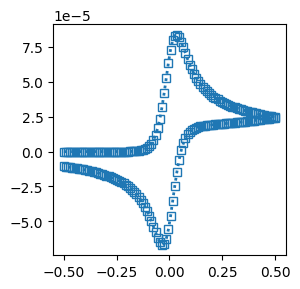

In [ ]:
# @title Figure 8
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.linestyle'] = ':'
plt.rcParams['lines.marker'] = 's'
plt.rcParams['lines.markerfacecolor'] = 'none'

fig, ax = plt.subplots(1,1,figsize=(3, 3))
ax.plot(E,i)

### Defining figure dimesions

The size of a figure should always be established in 1:1 scale with the intended use. Journals typically publish either single- or double-column figures, which are 8-9 cm or 17-18 cm, respectively. Modern presentation slides adopt a standard widescreen 16:9 aspect ratio, sized to be ~34 x 19 cm on the computer screen whereas older 4:3 slides are 25 x 19 cm. Hasty resizing of manuscript figures for a conference presentation by stretching and pulling the original impages leads to pixelated graphics and poorly spaced fonts. Instead, figures should be redrawn with the appropriate plotting variables.

Earlier, we used `figsize` to specify the dimensions of a multipanel figure. The default figure size can be set for each new figure or set globally in `rcParams` and is always specified in inches. Other units can be specified using a user-defined constant, possibly desirable for matching the specific figure sizes requested by a journal.

```python
mm = 1 / 25.4 #25.4 cm per inch
fig, ax = plt.subplots(figsize=(89*mm, 89*mm))
```

#### Font selection

Serif fonts (Times New Roman, Georgia, Courier) are preferable for dense text environments, particularly the body of a manuscript. This is because serifs (decorative additions to the ends of lines) make it easier to distinguish letters which are similar in structure. The capital leter I, the lower-case l, and the number 1 are easily distinguished by serifs but are rendered identically in most sans serif fonts, which may occasionally cause confusion. More importantly, the use of serifs supports easier identification of words amongnst dense blocks of text and allows readers to process information more quickly.

In contrast, sans serif fonts (Helvetica, Arial, Calibri) are preferable for figures, presentations, and posters because they reduce visual clutter. Figures are designed to be inspected and the data is the "main course". Because text is generally meant to serve as supplemental information (labels, legends, etc...) the use of sans serif fonts is more appropriate than dense blocks of serif fonts.

The intricate details of font design and selection are beyond the scope of the current text and we assume most will simply follow the specific journal-preferred font styles as appropriate. It is generally not necessary or useful to use more than 2 font types within a figure. Consider instead other forms of formatting (italics, bold, color) to provide emphasis. The specific font within a figure can be changed using keyword arguments, for example:

```python
ax.set_title('My Title', font='Helvetica')
```

The global settings can be modified at the start of a script using

```python
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']
```

which indicates that future objects will be created with a sans-serif font and sets the default sans-serif font to Helvetica.

Printed text is most often between font size 10-12, and font sizes less than 8 in figures will be difficult to read without magnification and may lead to pixelated text depending on the level of image compression.

#### Color schemes

Use a consistent, color scheme throughout your manuscript and presentations. Setting a color scheme at the beginning of a common script used to prepare figures is preferable.

Red-green color deficiencies are relatively common and any color containing red and green hues may be impacted. These two colors and others impacted by color-vision deficiencies will hinder the legibility of a figure. There are multiple online tools which can be used to check the visual appearance of a graphic as viewed by persons with color-vision deficiencies and best practices include (1) using secondary features (such as different marker/line styles) for data sets, which has the added benefit of preserving legibility in documents printed in grayscale and (2) using different hues, which lead to lighter/darker features regardless of color perception [[5]](#ramsey).

Issues with color selection are most common across categorical data sets, and although the default matplotlib color palette pairs red and green, other defaults from tableau and seaborn are available.

```python
plt.style.use('seaborn-v0_8-colorblind')
plt.style.use('tableau-colorblind10')
```

A custom string of colors can be defined by the user in place of the pre-defined colormaps included with matplotlib. As an example, we define the 8-color Okabe-Ito palette explicitly, which was developed as (Wang 2011 Nature Methods) and modify the default color cycler used by matplotlib for successive data sets added to a figure.

citation: https://www.nature.com/articles/nmeth.1618


```python
import matplotlib.pyplot as plt
from cycler import cycler

okabe_ito = [
    '#000000',  # Black
    '#E69F00',  # Orange
    '#56B4E9',  # Sky Blue
    '#009E73',  # Blue-Green
    '#F0E442',  # Yellow
    '#0072B2',  # Blue
    '#D55E00',  # Vermillion
    '#CC79A7',  # Reddish Purple
]

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=okabe_ito)
```

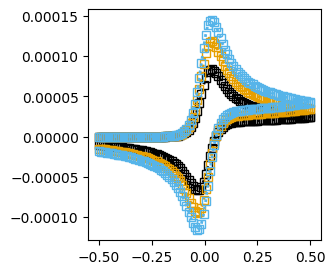

In [ ]:
# @title Figure 9
okabe_ito = [
    '#000000',  # Black
    '#E69F00',  # Orange
    '#56B4E9',  # Sky Blue
    '#009E73',  # Blue-Green
    '#F0E442',  # Yellow
    '#0072B2',  # Blue
    '#D55E00',  # Vermillion
    '#CC79A7',  # Reddish Purple
]

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=okabe_ito)

fig,ax = plt.subplots(1,1,figsize=(3,3))

ax.plot(E_10,i_10)
ax.plot(E_20,i_20)
ax.plot(E_30,i_30)

### Saving figures and file formats

Figures which are intended to be viewed outside of a notebook environment must be exported to a printable file format. This final step should not be an afterthought; poor selection of file types or image resolution may risk losing valuable information which was encoded in the figure-making process. A few guidelines for selecting a file format and image resolution are below.

#### Vector formats

Vector graphics store instructions for recreating the lines which compose a figure, rather than individual pixels. These instructions offer the benefit of preserving information as images are scaled up or down and are preferred for both print and online publishing. Vector graphics are thus particularly suitable for figures presenting cyclic voltammetry, current-time traces, or blends of lines and markers such as fitted Nyquist data. The most commonly used example is the "Portable Document Format" (`.pdf`) which is accepted by major academic publishers (*American Chemical Society*, *American Physical Society*) and appropriate for modern LaTeX typesetting workflows. Encapsulated PostScript (`.eps`) is still the preferred file format of many publishers whereas Scalable Vector Graphics (`.svg`) are the standard web-based illustrations.

```python
plt.savefig('fig_my_lineplot.png', format='pdf')
```

#### Bitmap formats

Bitmap formats store discrete pixels from an original image. These lead to larger files in comparison to vector formats and pixelation when images are scaled up from their original sizes. Tagged Image File Format (`.tiff`) and Portable Network Graphics (`.png`) preserve all of the original information of the image whereas Joint Photographic Experts Group (`.jpeg`) files are compressed to achieve smaller file sizes and are most at risk for pixelated images or other artefacts. Although these formats are most appropriate for photos or microscopy data, they may be more effective than vector formats when visualizing data as a heatmap or a very sense set of markers.

```python
plt.savefig('fig_my_plot.png', format='png')
```

#### Dots per inch (DPI)

Selecting an appropriate image resolution is a balance between preserving the original information of a figure with an acceptable file size. Most publishers require a minimum of 300 DPI for color images and higher resolution images may be requested for final publication. We recommend 300 DPI as a default setting, scaling the height and width appropriately for the final print format, and only selecting higher resolutions as required by publishers. Exporting files with resolution greater than 1200 DPI offers limited-to-no benefits in appearance but produces very large file sizes.

```python
plt.savefig('fig_my_plot.png', format='png', dpi=300)
```

#### Transparency

Figures are typically exported over a white background by default. This preserves the original representation of the figure but may lead to an unappealing contrast of the white background with some presentations or posters. Figures which are meant to be integrated with presentations, websites, or other formats where layering and a non-white background is possible, may be exported with a transparent background.

```python
plt.savefig('fig_my_plot.png', format='png', dpi=300, transparent=True)
```


#### Scaling axes for Nyquist plots

Nyquist plots are a common way of representing data from electrochemical impedance spectroscopy experiments. Effective Nyquist plots rely on careful attention to the figure axes and annotations and are used here as an advanced case study for professional figure design. By convention, the imaginary component of the impedance is plotted on a negative scale because capacitances are much more common than inductances in equivalent circuit models for electrochemical cells and thus the values are most often negative.

The Electrochemical Society has discussed guidelines for effective Nyquist plots, which include equal scaling of the x- and y-axes (orthonormal), annotation of specific frequencies along the data set, and representation of experimental data as discrete points with modeled data represented by continuous lines.

citation: https://www.electrochem.org/wp-content/uploads/2019/11/plot-rules.pdf

The default settings of most plotting software are designed to minimize whitespace, but this preference is often at odds with proper scaling of the x- and y-axes. Intead, Nyquist plots should generally include explicit definitions of axis ranges to allow easy visualization of the relative resistances of equivalent circuit elements.

The following example uses a model set of data for a Randles circuit

```python
# Define a set of equivalent circuit elements
R_s = 100       # R-sol (ohms)
R_ct = 500      # R-ct (ohms)
C_dl = 1e-6     # C-dl (F)

# Initialize values for frequency
freq = np.logspace(5, -1, 100)
omega = 2 * np.pi * freq

# Define the analytical solution for a Randles Circuit
Z = R_s + R_ct / (1 + 1j * omega * R_ct * C_dl)
Z_real = Z.real # Real Component
Z_imag = Z.imag # Imaginary Component

```
Assuming the plot contains experimental data, the data is best represented by discrete markers which indicate measured data points.

The maximum value of the real component of the impedance is typically larger than the maximum value of the imaginary component, and can often be used to define the plot range `xScale = max(Z_real)` without needing to further adjust the axis limits.
```python
# Initialize Plot
fig, ax = plt.subplots(figsize=(3, 3))
#By convention, the y-axis presents -Z_imag
ax.plot(Z_real, -1*Z_imag, linestyle='', marker='s', markerfacecolor='none')

# Set Axes
xScale = max(Z_real)
xmin=0
xmax=xScale * 1.1
ymin=0
ymax=xScale * 1.1
ymax=ymin + (xmax-xmin) # Equal scaling of x and y axis
ax.set_xlim(xmin, xmax) # Explicit definition of axes
ax.set_ylim(ymin, ymax)

ax.set_xlabel('Z(Re)')
ax.set_ylabel('-Z(Im)')
```
Although Nyquist data are collected at different frequencies, this information is not explicitly provided by either the x- or y-axis. For example, in a simple Randles circuit, the most important frequency is the value where `Z_imag` is maximized. This can be indicated on a plot with annotations, allowing the capacitance of the double layer to be directly calculated.

This point can be identified using trial and error, or, assuming the data has been collected with sufficient resolution, be identfied using numpy: `maxID = np.argmax(-Z_imag)`

The xytext offset often needs to be adjusted to ensure that the text does not overlap with markers or fitted lines and there are a number of different options availble which can be specified using the `arrowstyle` key: `'-'`, `'->'`, `'simple'`, `'wedge'`, etc...

```python
maxID = np.argmax(-Z_imag) # Index where peak -Z_imag occurs
label = f"{round(freq[maxID])} Hz" # Frequency label, rounded
ax.annotate(label, (Z_real[maxID], -Z_imag[maxID]), # Specify label and position
            xytext=(0,25), # Offest from label position
            textcoords='offset points', # Keyword for text offset
            arrowprops=dict(arrowstyle='-')) # Arrow for annotation
```

Text(0, 0.5, '-Z(Im)')

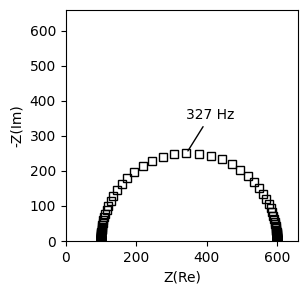

In [ ]:
# @title Figure 10
R_s = 100       # R-sol (ohms)
R_ct = 500      # R-ct (ohms)
C_dl = 1e-6     # C-dl (F)

freq = np.logspace(5, -1, 100)
omega = 2 * np.pi * freq

# Define the analytical solution for a Randles Circuit
Z = R_s + R_ct / (1 + 1j * omega * R_ct * C_dl)
Z_real = Z.real # Real Component
Z_imag = Z.imag # Imaginary Component * -1

# Initialize Plot
fig, ax = plt.subplots(figsize=(3, 3))
ax.plot(Z_real, -1*Z_imag, linestyle='', marker='s', markerfacecolor='none')

# Set Axes
xScale = max(Z_real)
xmin=0
xmax=xScale * 1.1
ymin=0
ymax=xScale * 1.1
ymax=ymin + (xmax-xmin) # Equal scaling of x and y axis
ax.set_xlim(xmin, xmax) # Explicit definition of axes
ax.set_ylim(ymin, ymax)

maxID = np.argmax(-Z_imag) # Index where peak -Z_imag occurs
label = f"{round(freq[maxID])} Hz" # Frequency label, rounded
ax.annotate(label, (Z_real[maxID], -Z_imag[maxID]), # Specify label and position
            xytext=(0,25), # Offest from label position
            textcoords='offset points', # Keyword for text offset
            arrowprops=dict(arrowstyle='-')) # Arrow for annotation

ax.set_xlabel('Z(Re)')
ax.set_ylabel('-Z(Im)')

## Section 4.1.5 Seaborn and visualizing statistical data sets

Seaborn is a visualization library built on matplotlib and is designed with statistics and large data sets in mind. The library was designed to simplify exploratory data analysis[[4]](#tukey) and automatically generates graphics with design features compared to similar figures generated in matplotlib.

citation: https://joss.theoj.org/papers/10.21105/joss.03021

Beyond its distinct visual appearance, Seaborn includes several functions which assist users in identifying relationships across datasets. Functions such as `pairplot` quickly generate a subplot matrix which combines every pairwise  relationship, allowing a user to search for correlations or anomalies across a complex variable set. Categorical summaries such as `violinplot` bring together quantitative distributions and provide a visual representation of summary statistics. Tools for slicing across datasets within an active figure, e.g. `relplot` or `catplot`, allow users to quickly visualize subsets of a larger data set using variations in color, markers, or subplots. For example, a battery researcher combing through a summary of cycling data might color code two different cell chemistries while studying how the measured cycle life was distributed for different categorical variables.

## Data for visualization

For the purposes of this introduction we have generated a set of synthetic battery data representing two different cell chemistries tested over four consecutive months. The data can be reproduced using the supporting code availalable online. A random number generator was seeded for reproducibility and cell data was prepared as a normal distribution with a standard deviation equal to 40% of the mean value in the first month and then 20% relative error in the following months. Cells with chemistry "A" were modified to systematically yield 100 more cycles than chemistry "B".

```python
# Initialize a reproducible random number generator
rng = np.random.default_rng(seed=2026)

# Data for 50 cells tested in a given month, with a 40% standard deviation
aug_cells = np.round(585*rng.normal(loc=1, scale=0.4, size=50))

# Add 50 cycles to cells with chemistry 'A'
df_cells.loc[df_cells['Chemistry'] == 'A', 'Cycle Life'] += 100
```

In [ ]:
# @title Synthetic Battery Data

# Create a synthetic data set for battery cells.
# This will not be included in the text but can be made available online.

# Initialize a reproducible random number generator
rng = np.random.default_rng(seed=2026)

# Data for cells tested in four months which differ in their average value
aug_cells = np.round(585*rng.normal(loc=1, scale=0.4, size=50))
sep_cells = np.round(600*rng.normal(loc=1, scale=0.2, size=50))
oct_cells = np.round(620*rng.normal(loc=1, scale=0.2, size=50))
nov_cells = np.round(630*rng.normal(loc=1, scale=0.2, size=50))

# Create a dictionary of the cell data
data = {
    'August': aug_cells,
    'September': sep_cells,
    'October': oct_cells,
    'November': nov_cells
}

# Populate the data with labels for two different cell chemistries
cell_chemistry = []
for month, cells in data.items():
    half_cells = len(cells) // 2
    cell_chemistry.extend(['A'] * half_cells)
    cell_chemistry.extend(['B'] * (len(cells) - half_cells))

# Convert the dictionary to a pandas DataFrame
df_cells = pd.DataFrame({
    'Month': sum([[month]*len(cells) for month, cells in data.items()], []),
    'Cycle Life': np.concatenate(list(data.values())),
    'Chemistry': cell_chemistry
})

# Add 50 to 'Cycle Life' for cells with 'Chemistry A'
df_cells.loc[df_cells['Chemistry'] == 'A', 'Cycle Life'] += 100

print(df_cells.head())
print(df_cells.tail())

    Month  Cycle Life Chemistry
0  August       499.0         A
1  August       741.0         A
2  August       241.0         A
3  August      1012.0         A
4  August       834.0         A
        Month  Cycle Life Chemistry
195  November       443.0         B
196  November       446.0         B
197  November       677.0         B
198  November       640.0         B
199  November       647.0         B


We begin our exploration with the versatile catplot function. Here, users can quickly toggle between different methods of exploring data to identify trends and possibly the presence of outliers. The `kind` parameter can be called with a number of different plot types which do not require further changes to the remaining plot parameters for proper execution. Categorical scatterplots (`strip`, `swarms`) present all of the discrete data simultaneously whereas categorical distribution plots process a subset of the data and summarize with filled in shapes (`box`, `violin`, `boxen`). Distributions are less accurate and potentially misleading for a small number of data points, but necessary when visualizing more than a few dozen statistically independent data points.

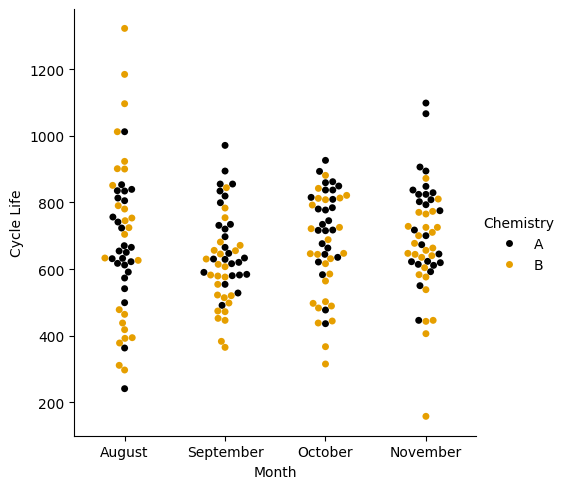

In [ ]:
# @title Figure 11a

import seaborn as sns
sns.catplot(data=df_cells,
            x="Month",
            y="Cycle Life",
            hue="Chemistry",
            kind="swarm")

In the above scatterplot, it is difficult to glean much information about the differences in cycle life over time, except for a wider range of data in the first month of testing. Some processing of the individual data points is necessary. The boxplot function is designed to calculate the necessary information for a box-and-whisker plot, recommended by Tukey, in a single line of code. The complete dataframe is passed as the first argument, with statistics related to the cycle life presented along the y-axis and cell chemistry data separated along the x-axis.

```python
import seaborn as sns
plt.figure(figsize=(3, 3))
sns.boxplot(data=df_cells, x='Chemistry', y='Cycle Life', color='gold')
```

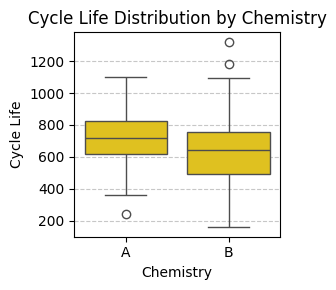

In [ ]:
# @title Figure 12
plt.figure(figsize=(3, 3))
sns.boxplot(data=df_cells, x='Chemistry', y='Cycle Life', color='gold')
plt.title('Cycle Life Distribution by Chemistry')
plt.xlabel('Chemistry')
plt.ylabel('Cycle Life')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


The central line presents the mean of each data set and the box encloses the inner quartiles (25-50% and 50-75%) of the data. The "whiskers" extend to enclose the full range of the data, with the exception of outliers which are represented here as open circles. Exclusion of outliers is accomplished using an inner-quartile-range (IQR) rule established by Tukey, where the whiskers can extend no further than 1.5 times the width of the box representing the IQR. The `whis` parameter can be used to modify this value (e.g. 2 or 3 times the IQR).

Comparing the mean values of chemistry A and B shows the expected difference in cycle life, but the difference is within a single quartile. This is in part due to imprecise data collected in the first month, and so we can further explore the relationship as measured in individual months of the experimental campaign.

```python
sns.boxplot(data=df_cells,
            x='Month',
            y='Cycle Life',
            hue='Chemistry',
            palette='pastel')
```

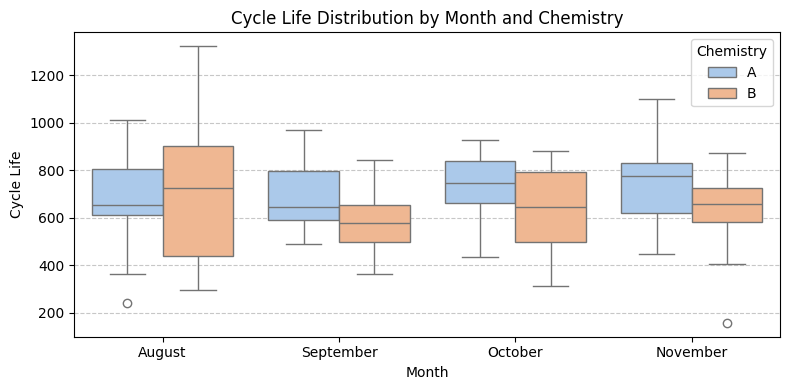

In [ ]:
# @title Figure 13

plt.figure(figsize=(8, 4))
sns.boxplot(data=df_cells, x='Month', y='Cycle Life', hue='Chemistry', palette='pastel')
plt.title('Cycle Life Distribution by Month and Chemistry')
plt.xlabel('Month')
plt.ylabel('Cycle Life')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

A few pieces of information pertinent to the experimentalist are quickly visualized by this expanded box plot. The change in "relative error" amongst the data set collected in August as compared to the latter months is apparent, and could indicate a more reliable procedure for cell assembly. The systematic improvement offered by chemistry "A" is apparent in the latter months, although notably the variability in chemistry "B" cells tested in August has masked systematic trends between cycle life, cell chemistry, and time.

### Large electrochemical data sets

Researchers in industry may have access to very large data sets which bring additional constraints for effective visualizations. Academic electrochemists are more often constrained by their ability to generate such data sets across experiments, but small time steps during intermittent titration testing or extended durability testing of electrolyzers and battery cells may lead to data series with millions of points. Combining thousands of overlapping data points is likely to obscure underlying trends and also lead to rendering issues.

A few strategies can lead to more effective visualizations. When the number of points are small enough to be rendered quickly, reducing the alpha transparency (`alpha = 0.05`) and marker size (`markersize=1`) will help readers to view where data points are dense based on regions of increasing darkness. Data density can also be visualized by summarizing the data set using bins (`plt.hexbin`). Two examples are provided below. In one example, the relative density of data points in Group B compared to group A is apparent, and the higher density regions of data are apparent for both. In a second example, the data are visualized using hexbins.

High-performance visualization engines such as `datashader` overcome rendering limitations by first binning data onto a fixed pixel grid before attempting to render an image. This allows one to quickly plot millions of discrete points without excessive use of memory.

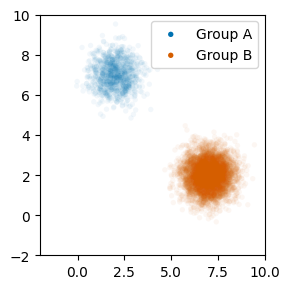

In [ ]:
# @title Figure 13
std_dev = 0.66
def_s = 15
def_a = 0.05

# Group A: 1000 points centered at [2, 7]
n_a = 1000
group_a_x = np.random.normal(loc=2, scale=std_dev, size=n_a)
group_a_y = np.random.normal(loc=7, scale=std_dev, size=n_a)

# Group B: 5000 points centered at [7, 2]
n_b = 5000
group_b_x = np.random.normal(loc=7, scale=std_dev, size=n_b)
group_b_y = np.random.normal(loc=2, scale=std_dev, size=n_b)


# Create Plot
fig, ax = plt.subplots(figsize=(3, 3))

# Plot with alpha=0.1 to visualize density and overlapping regions
ax.scatter(group_a_x, group_a_y, alpha=def_a, color='#0072B2', s=def_s, label='Group A', edgecolors='none')
ax.scatter(group_b_x, group_b_y, alpha=def_a, color='#D55E00', s=def_s, label='Group B', edgecolors='none')

# Styling and Labels
ax.set_xlim(-2, 10)
ax.set_ylim(-2, 10)

# Override the alpha in the legend so the markers are opaque and readable
leg = ax.legend(frameon=True)
for handle in leg.legend_handles:
    handle.set_alpha(1.0)

plt.tight_layout()
plt.show()

(-2.0, 10.0)

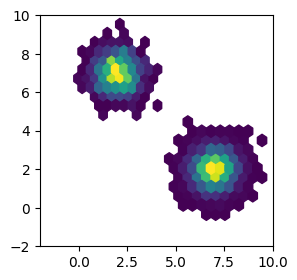

In [ ]:
# @title Figure 14
fig, ax = plt.subplots(figsize=(3, 3))

hb = ax.hexbin(group_a_x, group_a_y, # Load data
               gridsize=10, # Width of the grid
               cmap='viridis', # Colormap for visualizing data
               mincnt=1) # Minimum number of counts for color map

hb = ax.hexbin(group_b_x, group_b_y, gridsize=10, cmap='viridis', mincnt=1)

# Styling and Labels
ax.set_xlim(-2, 10)
ax.set_ylim(-2, 10)

## Section 4.1.6 Interactive and animated figures in Plotly

Static figures are a relic of legacy print publications, and modern plotting options provide ample opportunities for interactive figures and animations which make full use of web-based capabilities. Plotly is a library for rendering figures in a javascript environment which provides interactive functions that will be familiar to researchers used to visualizing their data within the plotting softwares included with potentiostats and battery cyclers. These features encourage users to engage with their data and allow easier exploration of different visualizations of regions within a voltammogram.

```python
import plotly.graph_objects as go

fig = go.Figure()
```
Creates a plotly Figure object which may be modified directly using `Figure.add_trace()` to add data or `Figure.update_layout()` to adjust the size, axis labels, title, or interactive settings of the plot.

As a representative example, we will plot a set of scan-rate dependent voltammetry data to investigate the zoom and hover features of plotly figure objects.

```python
fig.add_trace(go.Scatter(x=E_10, y=i_10, name='10 mV/s'))
fig.add_trace(go.Scatter(x=E_20, y=i_20, name='20 mV/s'))
fig.add_trace(go.Scatter(x=E_30, y=i_30, name='30 mV/s'))
```

The `add_trace()` function creates a new trace from a data object. Data is typically passed to the function as a "trace class", e.g. `plotly.graph_objects.Scatter` but can also be passed as a dictionary. A `Scatter` object includes x- and y-data and a name. Additional stylistic modifications are made to the `Scatter` object rather than being passed as parameters to the `add_trace()` function.

No plot is complete without axis labels and these are appended with the `Figure.update_layout()` function.

```python
fig.update_layout(
    xaxis_title='Potential (V vs. Ref)',
    yaxis_title='Current (A)', width=700, height=500
)

fig.show()
```

In [ ]:
# @title Figure 15
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(x=E_10, y=i_10, name='10 mV/s'))
fig.add_trace(go.Scatter(x=E_20, y=i_20, name='20 mV/s'))
fig.add_trace(go.Scatter(x=E_30, y=i_30, name='30 mV/s'))

fig.update_layout(
    xaxis_title='Potential (V vs. Ref)',
    yaxis_title='Current (A)', width=700, height=500
)

fig.update_layout(hovermode='x unified')

fig.show()

By default, hovering over specific points will display the x-value and y-value of the point as well as the name of the trace. When plotting multiple voltammetry traces, it is often useful to compare the specific values at a fixed voltage (the peak current) or current (the onset potential when comparing electrocatalysts). This is made possible by modifying `hovermode`.

```python
fig.update_layout(hovermode='x unified')

fig.show()
```

Using `matplotlib`, researchers wishing to investigate small redox peaks must iterate with different axes ranges and may miss interactive zooming functions present in most potentiostat software. Plotly provides Zoom In/Zoom Out functions (+/–) in the menu bar as well as a window Zoom function (Magnifying Glass Icon) to easily focus on specific peaks. Clicking on specific traces within the Figure legend will remove/add traces to the plot, particularly useful for decluttering a hover trace when comparing many traces at once. A specific view can be preserved as a .png file for a notebook using the Camera Icon...

For publication, these view settings should be reproduced with reproducible settings and exported using the standards discussed for `matplotlib`! This can be accomplished with the `plotly.io` and `kaleido` libraries.

```python
import plotly.io

# The kaleido library is needed for image export
# !pip install kaleido

plotly.io.write_image(fig, 'my_plotly_plot.svg', format='svg')
```

### Animating electrochemical data

Time is a hidden variable in any *i-E* plot of a cyclic voltammetry experiment. While an experienced electrochemist may intuit scan direction, the convolution of time and potential leads to misunderstandings and misinterpretations. One way to visualize time in a 2D projection is to *reanimate* the static data, displaying the sequence of potential and current data as they were viewed by the experimenter. Such visualizations are valuable tools for communicating experimental methods to lay audiences or for lectures on electrochemistry. Computer visualizations of data sets makes this possible and modern plotting libraries make this accessible. We will use the `plotly.express` library for this introduction because it is configured to directly convert data frames into animated plots.

```python
import plotly.express as px
```
A simple animation could show only the currently active data point, but most experimenters are accustomed to viewing the cumulative data collected up to a given instant. Thus, it would be helpful to prepare a set of frames where each frame represents all the data collected to the most recent data point, and these are created quickly using a for loop. A quick method using a single data frame is presented below.

```python
cumulative_data = []
for jj, t in enumerate(t_10):
    temp_df = pd.DataFrame({'E': E_10[:jj+1], 'i': i_10[:jj+1]})
    temp_df['Time'] = f"{t:.0f} s"
    cumulative_data.append(temp_df)

running_data = pd.concat(cumulative_data)
```
All the data in `running_data` is organized in a set of three columns and individual data series are organized by a time label. This is convenient for animating in `plotly.express` but could become unwieldy for very large data sets.

Next, we initialize our figure by passing the `running_data` data frame and assigning columns to the x- and y-axis. The animation frames are assigned to the time label and the ranges and initial axis limits and figure width are specified when generating the figure object. Note that the viewing window can be later modified with the interactive zoom functions as introduced above.

```python
fig = px.line(running_data, x="E", y="i",
              animation_frame="Time",
              range_x=[min(E_10)*1.1, max(E_10)*1.1],
              range_y=[min(i_10)*1.1, max(i_10)*1.1],
              width=700,
              height=500,
              labels={'E': 'Potential (V)', 'i': 'Current (A)'})
```

Lastly, we modify the time step (in milliseconds) to produce a suitable animation time. One option is to divide the total number of time steps by the desired animation time.

```python
animation_time = 5 # seconds
N_steps = t_10[-1] - t_10[0]
step_size = animation_time / N_steps * 1000 # milliseconds

fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = step_size
```

Alternatively one could modify the time step to represent some multiple of the time step used to collect the experimental data.

```python
t_step = t_10[1] - t_10[0]
step_size = t_step * 1000 / 100 # playback at 100x
```

The product of these efforts is an interactive figure which captures all three characteristic variables of a voltammetry experiment. These interactive figures are best suited for a web or notebook environment, but it is possible to export individual plot frames using the `imageio` and `kaleido` libraries.

In [ ]:
# @title Figure 16
import plotly.express as px

# Prepare cumulative data for the animation
cumulative_data = []
for i, t in enumerate(t_10):
    temp_df = pd.DataFrame({'E': E_10[:i+1], 'i': i_10[:i+1]})
    temp_df['Time'] = f"{t:.0f} s"
    cumulative_data.append(temp_df)

running_data = pd.concat(cumulative_data)

fig = px.line(running_data, x="E", y="i",
              animation_frame="Time",
              range_x=[min(E_10)*1.1, max(E_10)*1.1],
              range_y=[min(i_10)*1.1, max(i_10)*1.1],
              width=700,
              height=500,
              labels={'E': 'Potential (V)', 'i': 'Current (A)'})

# Find the index for the frame closest to t = 100 s
target_time = 100
frame_idx = int((np.abs(t_10 - target_time)).argmin())

# For visualization in print, start at the calculated frame (not discussed)
fig.layout.sliders[0].active = frame_idx
fig.update_traces(x=fig.frames[frame_idx].data[0].x, y=fig.frames[frame_idx].data[0].y)

t_step = t_10[1] - t_10[0]
step_size = t_step * 1000 / 50 # playback at 50x speed relative to real time
fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = step_size

fig.show()

# References

<div id="tufte">[1] Edward Tufte. The Visual Display of Quantitative Information. (1983).</div>

<div id="cleveland93">[2] William S. Cleveland. Visualizing Data (1993).</div>

<div id="tukey">[3] John Tukey. Exploratory Data Analysis. (1977).</div>

<div id="wilke">[4] Claus O. Wilke. Fundamentals of Data Visualization. (2019).</div>

<div id="ramsey">[4] H. Ramsey and I. Schröder. (2025). https://pubs.acs.org/doi/full/10.1021/acs.chas.4c00141 </div>
